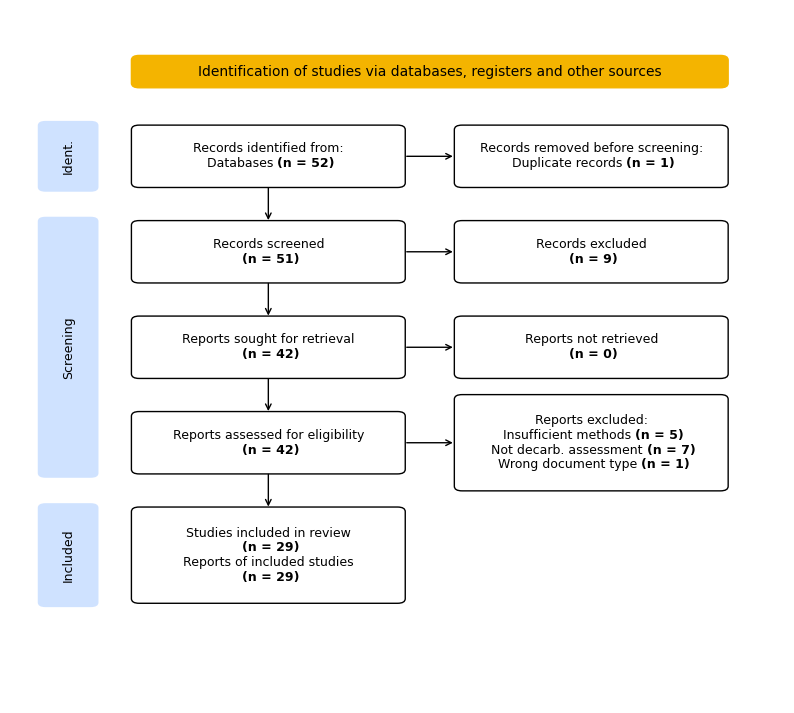

In [92]:
import sys
from unittest.mock import MagicMock
sys.modules['colrev'] = MagicMock()
sys.modules['colrev.loader'] = MagicMock()
sys.modules['colrev.loader.load_utils'] = MagicMock()

from prisma_flow_diagram import plot_prisma2020_new
from prisma_flow_diagram.prisma import PrismaStyle, Prisma2020Diagram, Widths, MatplotlibRenderer
import matplotlib.patches as patches
import re

# ── Tunable variables ─────────────────────────────────────────
HEADER_PADDING      = 0.5
COLUMN_WIDTH        = 2
IDENT_LABEL_HEIGHT  = 0.8
PHASE_LABEL_INSET   = 0.45
# ─────────────────────────────────────────────────────────────

# Reset patches to originals before re-applying (safe to re-run)
import importlib, prisma_flow_diagram.prisma as _pm
importlib.reload(_pm)
from prisma_flow_diagram.prisma import PrismaStyle, Prisma2020Diagram, Widths, MatplotlibRenderer

def _patched_widths(self, texts):
    return Widths(w_main_left=COLUMN_WIDTH, w_main_right=COLUMN_WIDTH,
                  w_other_left=0.0, w_other_right=0.0, w_included=COLUMN_WIDTH)
Prisma2020Diagram._compute_widths = _patched_widths

def _clean_draw_box(self, box, *, facecolor=None, edgecolor=None, fontsize=None, boxstyle=None):
    g = box.geometry()
    rect = patches.FancyBboxPatch(
        (g.left, g.bottom), g.width, g.height,
        boxstyle=boxstyle or self.style.boxstyle, linewidth=1,
        edgecolor=edgecolor or self.style.box_edge, facecolor=facecolor or self.style.box_face,
    )
    self.ax.add_patch(rect)
    fs = fontsize or self.style.box_fontsize
    lines = box.text.split('\n')
    line_height = 0.19
    total_h = (len(lines) - 1) * line_height
    start_y = g.center_y + total_h / 2
    for i, line in enumerate(lines):
        y = start_y - i * line_height
        parts = re.split(r'(\(n\s*=\s*[\d,]+\))', line)
        if len(parts) == 1:
            self.ax.text(g.center_x, y, line, ha='center', va='center', fontsize=fs)
        else:
            segments = [(p, bool(re.match(r'\(n\s*=\s*[\d,]+\)', p))) for p in parts if p]
            full_line = ''.join(p for p, _ in segments)
            dummy = self.ax.text(g.center_x, y, full_line, ha='center', va='center', fontsize=fs, alpha=0)
            self.ax.figure.canvas.draw()
            inv = self.ax.transData.inverted()
            bbox = dummy.get_window_extent()
            x0 = inv.transform([bbox.x0, bbox.y0])[0]
            x1 = inv.transform([bbox.x1, bbox.y0])[0]
            cur_x = g.center_x - (x1 - x0) / 2
            for seg_text, is_bold in segments:
                t = self.ax.text(cur_x, y, seg_text, ha='left', va='center',
                                 fontsize=fs, fontweight='bold' if is_bold else 'normal')
                self.ax.figure.canvas.draw()
                sb = t.get_window_extent()
                cur_x += inv.transform([sb.x1, sb.y0])[0] - inv.transform([sb.x0, sb.y0])[0]
    return g

MatplotlibRenderer.draw_box = _clean_draw_box

def _patched_phase_label(self, xc, yc, height, text):
    text = 'Ident.' if text == 'Identification' else text
    rect = patches.FancyBboxPatch(
        (xc - self.style.phase_bar_w / 2, yc - height / 2),
        self.style.phase_bar_w, height,
        boxstyle="round,pad=0.06", linewidth=0, facecolor=self.style.phase_face,
    )
    self.ax.add_patch(rect)
    self.ax.text(xc, yc, text, ha="center", va="center", rotation=90, fontsize=9)

MatplotlibRenderer.draw_phase_label = _patched_phase_label

YLIM_TOP = 9.0
HEADER_H = 0.3
HEADER_Y = YLIM_TOP - HEADER_H - HEADER_PADDING

plot_prisma2020_new(
    db_registers={
        'identification': {'databases': 52},
        'removed_before_screening': {'duplicates': 1},
        'records': {'screened': 51, 'excluded': 9},
        'reports': {
            'sought': 42, 'not_retrieved': 0, 'assessed': 42,
            'excluded_reasons': {
                'Not decarb. assessment': 7,
                'Insufficient methods': 5,
                'Wrong document type': 1,
            },
        },
    },
    included={'studies': 29, 'reports': 29},
    figsize=(12, 9),
    style=PrismaStyle(
        base_width=1.1, max_width=COLUMN_WIDTH, char_width=0.055, comfy_chars=22,
        col_gap=0.5, left_margin=1.0, right_margin=0.5,
        v_gap=0.55, ylim=(0.0, YLIM_TOP), header_y=HEADER_Y, header_h=HEADER_H,
        ident_phase_min_height=IDENT_LABEL_HEIGHT,
        phase_x=PHASE_LABEL_INSET,
        phase_bar_w=0.35,
    ),
    filename='prisma_steel_decarbonisation.svg',
)

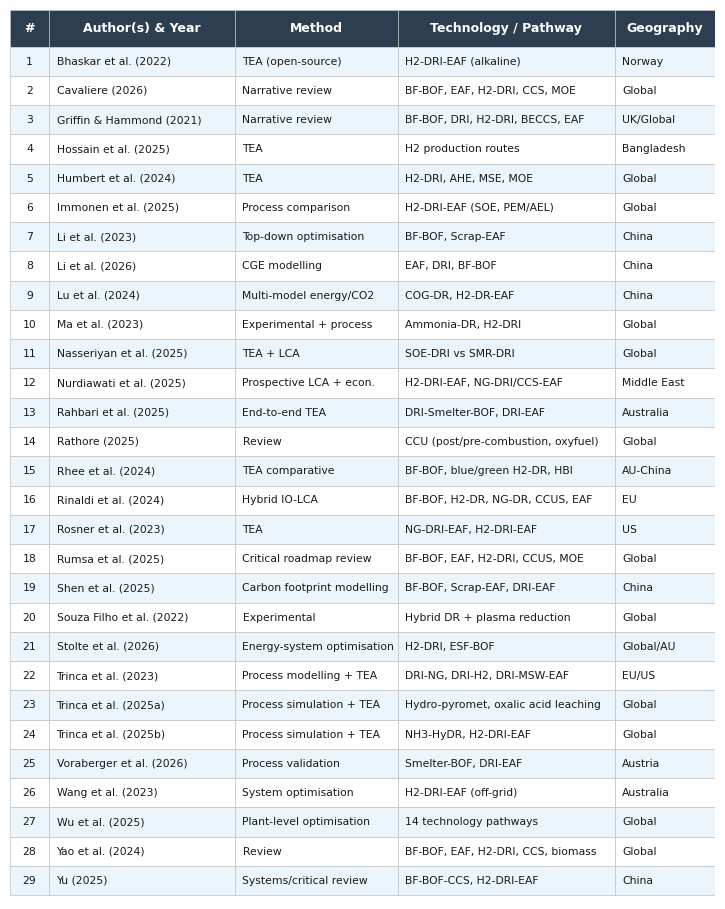

In [97]:
import matplotlib.pyplot as plt
import matplotlib.patches as mpatches

# ══════════════════════════════════════════════════════════════
# TABLE 1 — Study inventory (alphabetical by first author)
# ══════════════════════════════════════════════════════════════

papers = [
    (1,  "Bhaskar et al. (2022)",    "TEA (open-source)",          "H2-DRI-EAF (alkaline)",              "Norway"),
    (2,  "Cavaliere (2026)",         "Narrative review",           "BF-BOF, EAF, H2-DRI, CCS, MOE",     "Global"),
    (3,  "Griffin & Hammond (2021)", "Narrative review",           "BF-BOF, DRI, H2-DRI, BECCS, EAF",   "UK/Global"),
    (4,  "Hossain et al. (2025)",    "TEA",                        "H2 production routes",               "Bangladesh"),
    (5,  "Humbert et al. (2024)",    "TEA",                        "H2-DRI, AHE, MSE, MOE",             "Global"),
    (6,  "Immonen et al. (2025)",    "Process comparison",         "H2-DRI-EAF (SOE, PEM/AEL)",          "Global"),
    (7,  "Li et al. (2023)",         "Top-down optimisation",      "BF-BOF, Scrap-EAF",                 "China"),
    (8,  "Li et al. (2026)",         "CGE modelling",              "EAF, DRI, BF-BOF",                   "China"),
    (9,  "Lu et al. (2024)",         "Multi-model energy/CO2",     "COG-DR, H2-DR-EAF",                 "China"),
    (10, "Ma et al. (2023)",         "Experimental + process",     "Ammonia-DR, H2-DRI",                "Global"),
    (11, "Nasseriyan et al. (2025)", "TEA + LCA",                  "SOE-DRI vs SMR-DRI",                 "Global"),
    (12, "Nurdiawati et al. (2025)", "Prospective LCA + econ.",    "H2-DRI-EAF, NG-DRI/CCS-EAF",        "Middle East"),
    (13, "Rahbari et al. (2025)",    "End-to-end TEA",             "DRI-Smelter-BOF, DRI-EAF",           "Australia"),
    (14, "Rathore (2025)",           "Review",                     "CCU (post/pre-combustion, oxyfuel)", "Global"),
    (15, "Rhee et al. (2024)",       "TEA comparative",            "BF-BOF, blue/green H2-DR, HBI",     "AU-China"),
    (16, "Rinaldi et al. (2024)",    "Hybrid IO-LCA",              "BF-BOF, H2-DR, NG-DR, CCUS, EAF",  "EU"),
    (17, "Rosner et al. (2023)",     "TEA",                        "NG-DRI-EAF, H2-DRI-EAF",            "US"),
    (18, "Rumsa et al. (2025)",      "Critical roadmap review",    "BF-BOF, EAF, H2-DRI, CCUS, MOE",    "Global"),
    (19, "Shen et al. (2025)",       "Carbon footprint modelling", "BF-BOF, Scrap-EAF, DRI-EAF",         "China"),
    (20, "Souza Filho et al. (2022)","Experimental",               "Hybrid DR + plasma reduction",      "Global"),
    (21, "Stolte et al. (2026)",     "Energy-system optimisation", "H2-DRI, ESF-BOF",                    "Global/AU"),
    (22, "Trinca et al. (2023)",     "Process modelling + TEA",    "DRI-NG, DRI-H2, DRI-MSW-EAF",      "EU/US"),
    (23, "Trinca et al. (2025a)",    "Process simulation + TEA",   "Hydro-pyromet, oxalic acid leaching","Global"),
    (24, "Trinca et al. (2025b)",    "Process simulation + TEA",   "NH3-HyDR, H2-DRI-EAF",              "Global"),
    (25, "Voraberger et al. (2026)", "Process validation",         "Smelter-BOF, DRI-EAF",               "Austria"),
    (26, "Wang et al. (2023)",       "System optimisation",        "H2-DRI-EAF (off-grid)",             "Australia"),
    (27, "Wu et al. (2025)",         "Plant-level optimisation",   "14 technology pathways",             "Global"),
    (28, "Yao et al. (2024)",        "Review",                     "BF-BOF, EAF, H2-DRI, CCS, biomass", "Global"),
    (29, "Yu (2025)",                "Systems/critical review",    "BF-BOF-CCS, H2-DRI-EAF",            "China"),
]

# ── Tunable variables ─────────────────────────────────────────
T1_COL_WIDTHS = [0.5, 2.4, 2.1, 2.8, 1.3]
T1_HEADERS    = ["#", "Author(s) & Year", "Method", "Technology / Pathway", "Geography"]
T1_ROW_H      = 0.38
T1_HDR_H      = 0.48
T1_PAD        = 0.10
T1_FS_HDR     = 9
T1_FS_BODY    = 7.8
T1_HDR_FACE   = '#2C3E50'
T1_HDR_TEXT   = 'white'
T1_ROW_ALT    = '#EBF5FB'
T1_ROW_NORM   = 'white'
T1_GRID       = '#BDC3C7'
T1_TEXT       = '#1A1A1A'
# ─────────────────────────────────────────────────────────────

total_w = sum(T1_COL_WIDTHS)
total_h = T1_HDR_H + T1_ROW_H * len(papers) + 0.05

fig, ax = plt.subplots(figsize=(total_w, total_h))
ax.set_xlim(0, total_w)
ax.set_ylim(0, total_h)
ax.axis('off')
fig.patch.set_facecolor('white')

def cell(x, y, w, h, text, fc, tc, fs, bold=False, center=False):
    ax.add_patch(mpatches.Rectangle((x, y), w, h,
        facecolor=fc, edgecolor=T1_GRID, linewidth=0.5, zorder=2))
    tx = x + w/2 if center else x + T1_PAD
    ha = 'center' if center else 'left'
    ax.text(tx, y + h/2, text, ha=ha, va='center', fontsize=fs,
            color=tc, fontweight='bold' if bold else 'normal',
            fontfamily='DejaVu Sans', zorder=3)

x = 0
for hdr, cw in zip(T1_HEADERS, T1_COL_WIDTHS):
    cell(x, total_h - T1_HDR_H, cw, T1_HDR_H, hdr,
         T1_HDR_FACE, T1_HDR_TEXT, T1_FS_HDR, bold=True, center=True)
    x += cw

for r, row in enumerate(papers):
    y = total_h - T1_HDR_H - (r + 1) * T1_ROW_H
    fc = T1_ROW_ALT if r % 2 == 0 else T1_ROW_NORM
    x = 0
    for i, (val, cw) in enumerate(zip(row, T1_COL_WIDTHS)):
        cell(x, y, cw, T1_ROW_H, str(val), fc, T1_TEXT, T1_FS_BODY, center=(i == 0))
        x += cw

plt.savefig('table1_studies.svg', format='svg', bbox_inches='tight',
            facecolor='white', pad_inches=0.02)
plt.show()

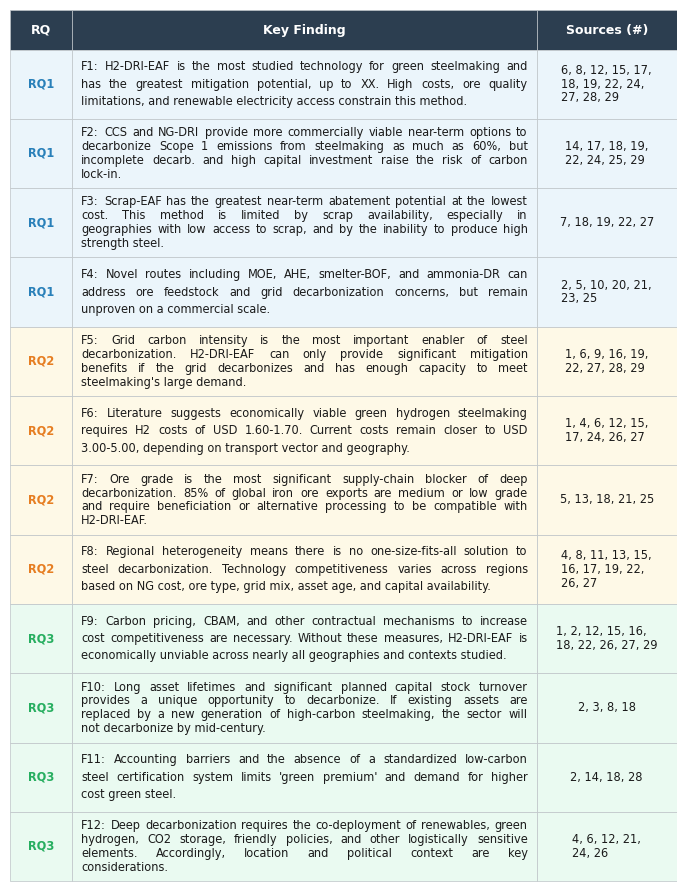

In [151]:
import matplotlib.pyplot as plt
import matplotlib.patches as mpatches
import textwrap

findings = [
    ("RQ1",
     "F1: H2-DRI-EAF is the most studied technology for green steelmaking and has the greatest mitigation potential, up to XX. High costs, ore quality limitations, and renewable electricity access constrain this method.",
     "6, 8, 12, 15, 17, 18, 19, 22, 24, 27, 28, 29"),
    ("RQ1",
     "F2: CCS and NG-DRI provide more commercially viable near-term options to decarbonize Scope 1 emissions from steelmaking as much as 60%, but incomplete decarb. and high capital investment raise the risk of carbon lock-in.",
     "14, 17, 18, 19, 22, 24, 25, 29"),
    ("RQ1",
     "F3: Scrap-EAF has the greatest near-term abatement potential at the lowest cost. This method is limited by scrap availability, especially in geographies with low access to scrap, and by the inability to produce high strength steel.",
     "7, 18, 19, 22, 27"),
    ("RQ1",
     "F4: Novel routes including MOE, AHE, smelter-BOF, and ammonia-DR can address ore feedstock and grid decarbonization concerns, but remain unproven on a commercial scale.",
     "2, 5, 10, 20, 21, 23, 25"),
    ("RQ2",
     "F5: Grid carbon intensity is the most important enabler of steel decarbonization. H2-DRI-EAF can only provide significant mitigation benefits if the grid decarbonizes and has enough capacity to meet steelmaking's large demand.",
     "1, 6, 9, 16, 19, 22, 27, 28, 29"),
    ("RQ2",
     "F6: Literature suggests economically viable green hydrogen steelmaking requires H2 costs of USD 1.60-1.70. Current costs remain closer to USD 3.00-5.00, depending on transport vector and geography.",
     "1, 4, 6, 12, 15, 17, 24, 26, 27"),
    ("RQ2",
     "F7: Ore grade is the most significant supply-chain blocker of deep decarbonization. 85% of global iron ore exports are medium or low grade and require beneficiation or alternative processing to be compatible with H2-DRI-EAF.",
     "5, 13, 18, 21, 25"),
    ("RQ2",
     "F8: Regional heterogeneity means there is no one-size-fits-all solution to steel decarbonization. Technology competitiveness varies across regions based on NG cost, ore type, grid mix, asset age, and capital availability.",
     "4, 8, 11, 13, 15, 16, 17, 19, 22, 26, 27"),
    ("RQ3",
     "F9: Carbon pricing, CBAM, and other contractual mechanisms to increase cost competitiveness are necessary. Without these measures, H2-DRI-EAF is economically unviable across nearly all geographies and contexts studied.",
     "1, 2, 12, 15, 16, 18, 22, 26, 27, 29"),
    ("RQ3",
     "F10: Long asset lifetimes and significant planned capital stock turnover provides a unique opportunity to decarbonize. If existing assets are replaced by a new generation of high-carbon steelmaking, the sector will not decarbonize by mid-century.",
     "2, 3, 8, 18"),
    ("RQ3",
     "F11: Accounting barriers and the absence of a standardized low-carbon steel certification system limits 'green premium' and demand for higher cost green steel.",
     "2, 14, 18, 28"),
    ("RQ3",
     "F12: Deep decarbonization requires the co-deployment of renewables, green hydrogen, CO2 storage, friendly policies, and other logistically sensitive elements. Accordingly, location and political context are key considerations.",
     "4, 6, 12, 21, \n   24, 26"),
]

# ── Tunable variables ─────────────────────────────────────────
T2_COL_WIDTHS  = [0.8, 6, 1.8]
T2_HEADERS     = ["RQ", "Key Finding", "Sources (#)"]
T2_ROW_H       = 0.9
T2_HDR_H       = 0.52
T2_PAD         = 0.12
T2_FS_HDR      = 9
T2_FS_BODY     = 8.2
T2_WRAP_CHARS  = 74
T2_WRAP_PAPERS = 18
T2_JUSTIFY     = True    # ← toggle justified text in finding column
T2_HDR_FACE    = '#2C3E50'
T2_HDR_TEXT    = 'white'
T2_ROW_COLORS  = {'RQ1': '#EBF5FB', 'RQ2': '#FEF9E7', 'RQ3': '#EAFAF1'}
T2_RQ_COLORS   = {'RQ1': '#2980B9', 'RQ2': '#E67E22', 'RQ3': '#27AE60'}
T2_GRID        = '#BDC3C7'
T2_TEXT        = '#1A1A1A'
# ─────────────────────────────────────────────────────────────

total_w = sum(T2_COL_WIDTHS)
total_h = T2_HDR_H + T2_ROW_H * len(findings) + 0.05

fig, ax = plt.subplots(figsize=(total_w, total_h))
ax.set_xlim(0, total_w)
ax.set_ylim(0, total_h)
ax.axis('off')
fig.patch.set_facecolor('white')

def get_text_width_data(ax, text, fs, bold):
    """Render invisible text and return its width in data coordinates."""
    t = ax.text(0, 0, text, fontsize=fs, fontfamily='DejaVu Sans',
                fontweight='bold' if bold else 'normal', alpha=0)
    fig.canvas.draw()
    bb = t.get_window_extent()
    inv = ax.transData.inverted()
    x0 = inv.transform([bb.x0, bb.y0])[0]
    x1 = inv.transform([bb.x1, bb.y0])[0]
    t.remove()
    return x1 - x0

def draw_justified_text(ax, x_start, y, cell_w, h, lines, fs, tc, bold, pad):
    """Draw each line with word spacing adjusted to fill cell_w."""
    n_lines = len(lines)
    line_h = h / (n_lines + 1)
    text_right = x_start + cell_w - pad

    for li, line in enumerate(lines):
        line_y = y + h - line_h * (li + 1)
        words = line.split()
        is_last_line = (li == n_lines - 1)

        if len(words) <= 1 or is_last_line:
            # Don't justify last line or single-word lines
            ax.text(x_start + pad, line_y, line,
                    ha='left', va='center', fontsize=fs, color=tc,
                    fontweight='bold' if bold else 'normal',
                    fontfamily='DejaVu Sans', zorder=3)
        else:
            # Measure total word widths
            word_widths = [get_text_width_data(ax, w, fs, bold) for w in words]
            total_word_w = sum(word_widths)
            available_w = cell_w - 2 * pad
            gap = (available_w - total_word_w) / (len(words) - 1)
            cx = x_start + pad
            for wi, (word, ww) in enumerate(zip(words, word_widths)):
                ax.text(cx, line_y, word, ha='left', va='center',
                        fontsize=fs, color=tc,
                        fontweight='bold' if bold else 'normal',
                        fontfamily='DejaVu Sans', zorder=3)
                cx += ww + gap

def cell(x, y, w, h, text, fc, tc, fs, bold=False, center=False,
         wrap_chars=None, justify=False):
    ax.add_patch(mpatches.Rectangle((x, y), w, h,
        facecolor=fc, edgecolor=T2_GRID, linewidth=0.5, zorder=2))
    if wrap_chars:
        text = textwrap.fill(text, width=wrap_chars)
    if justify and wrap_chars:
        lines = text.split('\n')
        draw_justified_text(ax, x, y, w, h, lines, fs, tc, bold, T2_PAD)
    else:
        tx = x + w/2 if center else x + T2_PAD
        ha = 'center' if center else 'left'
        ax.text(tx, y + h/2, text, ha=ha, va='center', fontsize=fs,
                color=tc, fontweight='bold' if bold else 'normal',
                fontfamily='DejaVu Sans', zorder=3, multialignment='left')

# Header
x = 0
for hdr, cw in zip(T2_HEADERS, T2_COL_WIDTHS):
    cell(x, total_h - T2_HDR_H, cw, T2_HDR_H, hdr,
         T2_HDR_FACE, T2_HDR_TEXT, T2_FS_HDR, bold=True, center=True)
    x += cw

# Rows
for r, (rq, finding, papers_str) in enumerate(findings):
    y = total_h - T2_HDR_H - (r + 1) * T2_ROW_H
    fc = T2_ROW_COLORS[rq]
    x = 0
    for i, (val, cw) in enumerate(zip([rq, finding, papers_str], T2_COL_WIDTHS)):
        is_rq = (i == 0)
        is_papers = (i == 2)
        tc = T2_RQ_COLORS[rq] if is_rq else T2_TEXT
        wrap = T2_WRAP_CHARS if i == 1 else (T2_WRAP_PAPERS if is_papers else None)
        cell(x, y, cw, T2_ROW_H, val, fc, tc, T2_FS_BODY,
             bold=is_rq, center=(is_rq or is_papers),
             wrap_chars=wrap, justify=(T2_JUSTIFY and i == 1))
        x += cw

plt.savefig('table2_findings.svg', format='svg', bbox_inches='tight',
            facecolor='white', pad_inches=0.02)
plt.show()